^TNX (미국 10년물 국채 금리) 데이터 수집 중...


[*********************100%***********************]  1 of 1 completed


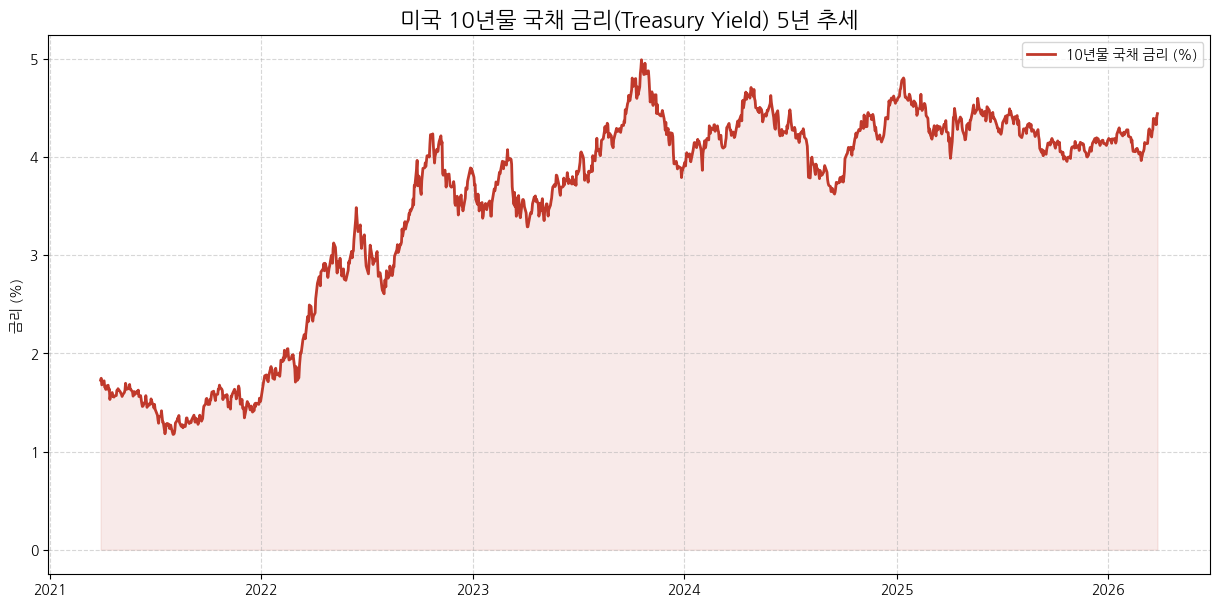

현재 국채 금리: 4.44%


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
from datetime import datetime, timedelta

# 1. 데이터 수집 (10-Year Treasury Yield: ^TNX)
ticker = "^TNX"
end = datetime.now()
start = end - timedelta(days=5*365)

print(f"{ticker} (미국 10년물 국채 금리) 데이터 수집 중...")
df = yf.download(ticker, start=start, end=end)

# Multi-index 대응
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 2. CSV 저장
df.to_csv("us_10y_treasury_5yr.csv")

# 3. 시각화
plt.figure(figsize=(15, 7))
plt.plot(df.index, df['Close'], color='#C0392B', linewidth=2, label='10년물 국채 금리 (%)')

# 주요 금리 변곡점 표시 (예: 제로금리 시기 등)
plt.fill_between(df.index, df['Close'], color='#C0392B', alpha=0.1)

plt.title('미국 10년물 국채 금리(Treasury Yield) 5년 추세', fontsize=16)
plt.ylabel('금리 (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

df.shape